In [34]:
%matplotlib inline

import os
import sys
import math

from sys import platform

sys.path.append('../../')

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from importlib.metadata import version 

import tiktoken

import torch
import torch.nn as nn



%load_ext autoreload
%autoreload 2

from llm_from_scratch.CH4.gpt import GPTModel
from llm_from_scratch.CH4.llama import Llama2Model, Llama3Model
from llm_from_scratch.CH4.blocks import RMSNorm, SiLU, MultiheadAttentionLlama, FeedForwardLlama, GroupedQueryAttention
from llm_from_scratch.CH4.utils import precompute_rope_params, compute_rope, calc_model_memory_size
from llm_from_scratch.CH2.text_data_set import create_dataloader_v1
from llm_from_scratch.CH5.loss import calc_loss_batch
from llm_from_scratch.CH5.utils import find_highest_gradient, load_weights_into_llama3
from llm_from_scratch.CH5.optim import evaluate_model, generate_and_print_sample
from llm_from_scratch.CH5.utils import token_ids_to_text, text_to_token_ids, generate, Tokenizer
from llm_from_scratch.CH5.chat_format import ChatFormat, clean_text
print(f"torch version: {version('torch')}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch version: 2.12.0


In [2]:
from importlib.metadata import version

pkgs=['blobfile',        # to download pretrained weights
      'huggingface_hub', # to download pretrained weights
      'matplotlib',      # to visualize RoPE with different base frequencies
      'tiktoken',        # to implement the tokenizer
      'torch',           # to implement the model
     ]
for p in pkgs: print(f"{p} version: {version(p)}")

blobfile version: 3.2.0
huggingface_hub version: 1.14.0
matplotlib version: 3.10.9
tiktoken version: 0.12.0
torch version: 2.12.0


In [42]:
theta_base=500_000.
exponent = torch.arange(0, head_dim, 2)[:(head_dim//2)].float()/head_dim # (head_dim//2,) ranging (0,1), i.e., never = or > 1
theta_i = theta_base ** exponent # (head_dim//2,) # monotonically decreasing function
print(f"{exponent=}")
print(f"{theta_i=}")
print(f"{1./theta_i=}")

exponent=tensor([0.0000, 0.1250, 0.2500, 0.3750, 0.5000, 0.6250, 0.7500, 0.8750])
theta_i=tensor([1.0000e+00, 5.1567e+00, 2.6591e+01, 1.3712e+02, 7.0711e+02, 3.6463e+03,
        1.8803e+04, 9.6961e+04])
1./theta_i=tensor([1.0000e+00, 1.9392e-01, 3.7606e-02, 7.2927e-03, 1.4142e-03, 2.7425e-04,
        5.3183e-05, 1.0313e-05])


i=tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
        37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
        55, 56, 57, 58, 59, 60, 61, 62, 63, 64])


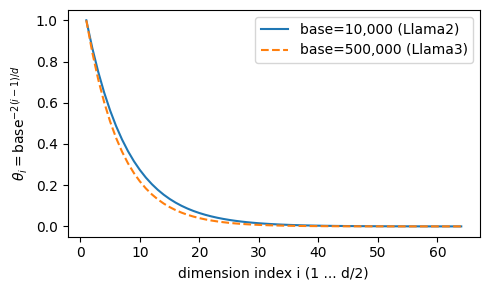

In [48]:
d=128 # embedding dimension
i=torch.arange(1, d//2+1)
print(f"{i=}")

base_llama2=10_000
base_llama3=500_00

theta_llama2=base_llama2 ** (-2*(i-1)/d)
theta_llama3=base_llama3 ** (-2*(i-1)/d)

plt.figure(figsize=(5,3))
plt.plot(i, theta_llama2, label="base=10,000 (Llama2)")
plt.plot(i, theta_llama3, label="base=500,000 (Llama3)", ls='--')
plt.xlabel('dimension index i (1 ... d/2)')
plt.ylabel(r"$\theta_i=\mathrm{base}^{-2(i-1)/d}$")
plt.legend()
plt.tight_layout()

wavelen[:5]=tensor([ 6.2832,  7.4405,  8.8109, 10.4338, 12.3556])
wavelen[-5:]=tensor([134909.5938, 159758.6094, 189184.5469, 224030.4688, 265294.6562])
low_freq_wavelen=8192.0, high_freq_wavelen=2048.0
theta_llama3[:5]=tensor([1.0000, 0.8445, 0.7131, 0.6022, 0.5085])
theta_llama3[-5:]=tensor([4.6573e-05, 3.9329e-05, 3.3212e-05, 2.8046e-05, 2.3684e-05])
inv_freq_llama[:5]=tensor([1.0000, 0.8445, 0.7131, 0.6022, 0.5085])
inv_freq_llama[-5:]=tensor([5.8217e-06, 4.9162e-06, 4.1515e-06, 3.5058e-06, 2.9605e-06])


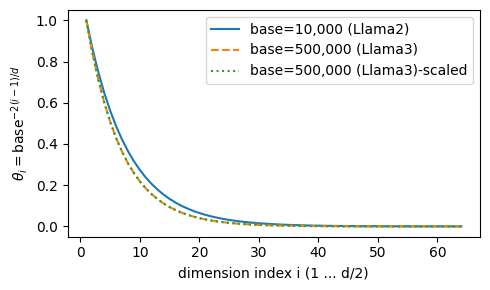

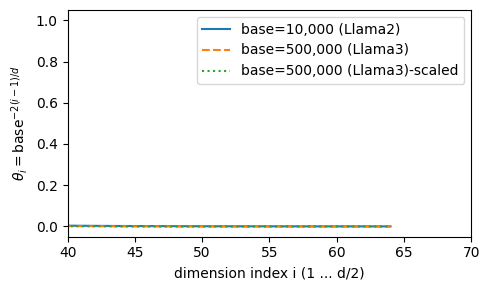

In [50]:
wavelen=2*torch.pi/theta_llama3
print(f"{wavelen[:5]=}\n{wavelen[-5:]=}")

rope_freq={
    "factor":8.,
    "low_freq_factor":1.,
    "high_freq_factor":4.,
    "original_context_length":8192,
}
# zone 1: wavelength>low_freq_wavelen (long distance - spanning across the entire context window): linear scaled
low_freq_wavelen=rope_freq['original_context_length']/rope_freq['low_freq_factor'] 
# zone 2: wavelength < high_freq_wavelen (short distance -- local token relationship) : unscaled
high_freq_wavelen=rope_freq['original_context_length']/rope_freq['high_freq_factor']
print(f"{low_freq_wavelen=}, {high_freq_wavelen=}")

inv_freq_llama=torch.where(wavelen>low_freq_wavelen, theta_llama3/rope_freq['factor'], theta_llama3)
print(f"{theta_llama3[:5]=}\n{theta_llama3[-5:]=}")
print(f"{inv_freq_llama[:5]=}\n{inv_freq_llama[-5:]=}")

plt.figure(figsize=(5,3))
plt.plot(i, theta_llama2, label="base=10,000 (Llama2)")
plt.plot(i, theta_llama3, label="base=500,000 (Llama3)", ls='--')
plt.plot(i, inv_freq_llama, label="base=500,000 (Llama3)-scaled", ls=':')
plt.xlabel('dimension index i (1 ... d/2)')
plt.ylabel(r"$\theta_i=\mathrm{base}^{-2(i-1)/d}$")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(5,3))
plt.plot(i, theta_llama2, label="base=10,000 (Llama2)")
plt.plot(i, theta_llama3, label="base=500,000 (Llama3)", ls='--')
plt.plot(i, inv_freq_llama, label="base=500,000 (Llama3)-scaled", ls=':')
plt.xlabel('dimension index i (1 ... d/2)')
plt.ylabel(r"$\theta_i=\mathrm{base}^{-2(i-1)/d}$")
plt.xlim([40,70])
plt.legend()
plt.tight_layout()

In [4]:
# instantiate RoPE parameters

llama_2_context_len=4096
llama_3_context_len=8192

llama_2_theta_base=10_000
llama_3_theta_base=500_000

# settings
batch_size=2
num_heads=4
head_dim=16

# instantiate RoPE parameters
cos, sin=precompute_rope_params(head_dim=head_dim, theta_base=llama_3_theta_base, context_length=llama_3_context_len)
print(f"{cos.shape=}, {sin.shape}")

# dummy query and key tensors
torch.manual_seed(123)
queries=torch.rand(batch_size, num_heads, llama_3_context_len, head_dim)
keys=torch.rand(batch_size, num_heads, llama_3_context_len, head_dim)

# apply rotary position embeddings
queries_rot=compute_rope(queries, cos, sin)
keys_rot=compute_rope(keys, cos, sin)
print(f"{queries.shape=}, {keys.shape}")
print(f"{queries_rot.shape=}, {keys_rot.shape=}")

cos.shape=torch.Size([8192, 16]), torch.Size([8192, 16])
queries.shape=torch.Size([2, 4, 8192, 16]), torch.Size([2, 4, 8192, 16])
queries_rot.shape=torch.Size([2, 4, 8192, 16]), keys_rot.shape=torch.Size([2, 4, 8192, 16])


### Group query attention and Mukltihead attention

In [5]:
# settings
batch_size=1
context_len=3000
max_context_len=8192
embed_dim=4096
num_heads=32

example_batch=torch.rand(batch_size, context_len, embed_dim)

mha=MultiheadAttentionLlama(d_in=embed_dim, d_out=embed_dim, context_length=max_context_len, num_heads=num_heads)
out=mha(example_batch)
print(f"{out.shape=}")
print(f"W_key: {mha.W_key.weight.shape=}")
print(f"W_value: {mha.W_value.weight.shape=}")
print(f"W_query: {mha.W_query.weight.shape=}")
del out

out.shape=torch.Size([1, 3000, 4096])
W_key: mha.W_key.weight.shape=torch.Size([4096, 4096])
W_value: mha.W_value.weight.shape=torch.Size([4096, 4096])
W_query: mha.W_query.weight.shape=torch.Size([4096, 4096])


In [6]:
gqa=GroupedQueryAttention(d_in=embed_dim, d_out=embed_dim, num_heads=num_heads, num_kv_groups=8)
out=gqa(example_batch)
print(f"{out.shape=}")
print(f"W_key: {gqa.W_key.weight.shape=}")
print(f"W_value: {gqa.W_value.weight.shape=}")
print(f"W_query: {gqa.W_query.weight.shape=}")
del out

out.shape=torch.Size([1, 3000, 4096])
W_key: gqa.W_key.weight.shape=torch.Size([1024, 4096])
W_value: gqa.W_value.weight.shape=torch.Size([1024, 4096])
W_query: gqa.W_query.weight.shape=torch.Size([4096, 4096])


In [7]:
print("Total number of parameters")

mha_total_parameters=sum(p.numel() for p in mha.parameters())
gqa_total_parameters=sum(p.numel() for p in gqa.parameters())
print(f"{mha_total_parameters=:,}, {gqa_total_parameters=:,}")

Total number of parameters
mha_total_parameters=67,108,864, gqa_total_parameters=41,943,040


In [8]:
del mha, gqa

### Llama3

In [9]:
LLAMA2_CONFIG_7B={
    "vocab_size":32_000,   # vocabulary size
    "context_length":4096, # context length
    "emb_dim":4096,        # embedding dimension
    "n_heads":32,          # number of attention heads
    "n_layers":32,         # number of layers
    "hidden_dim":11_008,   # size of the intermediate dimension in FeedForward
    "dtype":torch.bfloat16 # lower precision dtype to reduce memory usage
}

LLAMA3_CONFIG_8B={
    "vocab_size":128_256,  # vocabulary size
    "context_length":8192, # context length
    "emb_dim":4096,        # embedding dimension
    "n_heads":32,          # number of attention heads
    "n_layers":32,         # number of layers
    "hidden_dim":14_336,   # size of the intermediate dimension in FeedForward
    "n_kv_groups":8,       # key-value groups for grouped-query attention
    "rope_base":500_000.0, # base in RoPE's theta was increased to 500_000
    "rope_freq":None,      # additional configuration for adjusting RoPE frequencies
    "dtype":torch.bfloat16 # lower precision dtype to reduce memory usage
}

model=Llama3Model(LLAMA3_CONFIG_8B) # roughly 34GB compared to 26GB for Llama2
total_params=sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 8,030,261,248


In [10]:
print(f"float32 (pytorch default): {calc_model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16 (pytorch default): {calc_model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

float32 (pytorch default): 59.84 GB
bfloat16 (pytorch default): 29.92 GB


In [11]:
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.mps.is_available() else torch.device('cpu')
model.to(device);

In [12]:


from huggingface_hub import login

login(token=access_token)


/Users/reaungamornrat.sureerat/miniforge3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from huggingface_hub import hf_hub_download

tokenizer_file_path=hf_hub_download(repo_id="meta-llama/Meta-Llama-3-8B",
                                   filename="original/tokenizer.model",
                                   local_dir="/Users/reaungamornrat.sureerat/data/Llama3/Llama-3-8B")

In [14]:
model

Llama3Model(
  (tok_emb): Embedding(128256, 4096)
  (trf_blocks): Sequential(
    (0): TransformerBlockLlama(
      (att): GroupedQueryAttention(
        (W_key): Linear(in_features=4096, out_features=1024, bias=False)
        (W_value): Linear(in_features=4096, out_features=1024, bias=False)
        (W_query): Linear(in_features=4096, out_features=4096, bias=False)
        (out_proj): Linear(in_features=4096, out_features=4096, bias=False)
      )
      (ff): FeedForwardLlama(
        (fc1): Linear(in_features=4096, out_features=14336, bias=False)
        (fc2): Linear(in_features=4096, out_features=14336, bias=False)
        (fc3): Linear(in_features=14336, out_features=4096, bias=False)
        (silu): SiLU()
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
    (1): TransformerBlockLlama(
      (att): GroupedQueryAttention(
        (W_key): Linear(in_features=4096, out_features=1024, bias=False)
        (W_value): Linear(in_features=4096, out_features=1024, bias=False

In [15]:
tokenizer=Tokenizer(tokenizer_file_path)

torch.manual_seed(123)
token_ids=generate(model=model, idx=text_to_token_ids("Every effort", tokenizer).to(device), max_new_tokens=30, 
                   context_size=LLAMA3_CONFIG_8B['context_length'], top_k=1, temperature=0.)
print(f"Output text: {token_ids_to_text(token_ids, tokenizer)}")

Output text: Every effort foundation#defineдыuxtappayment Emmy(sender ＼ SAMPLE महत SLOT printing-ext Bee گرفته dialCorpishingЕТ 以onomies	Y dungeonGetX isc initializedHTMLElement splits prosecution<|reserved_223|>


### Load pretrained weights

In [16]:
from safetensors.torch import load_file

In [17]:
combined_weights={}

for i in range(1,5):
    weights_file=hf_hub_download(repo_id="meta-llama/Meta-Llama-3-8B", filename=f"model-0000{i}-of-00004.safetensors",
                                 local_dir= "/Users/reaungamornrat.sureerat/data/Llama3/Llama-3-8B")
    current_weights=load_file(weights_file)
    combined_weights.update(current_weights)
    print(f"{len(combined_weights)}: {combined_weights.keys()}")

82: dict_keys(['model.embed_tokens.weight', 'model.layers.0.input_layernorm.weight', 'model.layers.0.mlp.down_proj.weight', 'model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight', 'model.layers.0.post_attention_layernorm.weight', 'model.layers.0.self_attn.k_proj.weight', 'model.layers.0.self_attn.o_proj.weight', 'model.layers.0.self_attn.q_proj.weight', 'model.layers.0.self_attn.v_proj.weight', 'model.layers.1.input_layernorm.weight', 'model.layers.1.mlp.down_proj.weight', 'model.layers.1.mlp.gate_proj.weight', 'model.layers.1.mlp.up_proj.weight', 'model.layers.1.post_attention_layernorm.weight', 'model.layers.1.self_attn.k_proj.weight', 'model.layers.1.self_attn.o_proj.weight', 'model.layers.1.self_attn.q_proj.weight', 'model.layers.1.self_attn.v_proj.weight', 'model.layers.2.input_layernorm.weight', 'model.layers.2.mlp.down_proj.weight', 'model.layers.2.mlp.gate_proj.weight', 'model.layers.2.mlp.up_proj.weight', 'model.layers.2.post_attention_layernorm.weight', 'm

In [18]:
print(list(combined_weights.keys())[:15])

['model.embed_tokens.weight', 'model.layers.0.input_layernorm.weight', 'model.layers.0.mlp.down_proj.weight', 'model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight', 'model.layers.0.post_attention_layernorm.weight', 'model.layers.0.self_attn.k_proj.weight', 'model.layers.0.self_attn.o_proj.weight', 'model.layers.0.self_attn.q_proj.weight', 'model.layers.0.self_attn.v_proj.weight', 'model.layers.1.input_layernorm.weight', 'model.layers.1.mlp.down_proj.weight', 'model.layers.1.mlp.gate_proj.weight', 'model.layers.1.mlp.up_proj.weight', 'model.layers.1.post_attention_layernorm.weight']


In [22]:
load_weights_into_llama3(model, param_config=LLAMA3_CONFIG_8B, params=combined_weights, use_name=False)
model.to(device);

torch.manual_seed(123)
token_ids=generate(model=model, idx=text_to_token_ids("Every effect", tokenizer).to(device), max_new_tokens=25, 
                   context_size=LLAMA3_CONFIG_8B['context_length'], top_k=1, temperature=0.)
print(f"Output text: {token_ids_to_text(token_ids, tokenizer)}")

Output text: Every effect is a cause, and every cause is an effect. The world is a web of causes and effects, and the web is


In [23]:
del combined_weights

### Using instruction-finetuned model

In [26]:
import gc

del model

gc.collect() # run python garbage collector

if torch.cuda.is_available(): torch.cuda.empty_cache()

In [27]:
combined_weights={}
for i in range(1,5):
    weights_file=hf_hub_download(repo_id="meta-llama/Meta-Llama-3-8B-Instruct",
                                filename=f"model-0000{i}-of-00004.safetensors",
                                local_dir="/Users/reaungamornrat.sureerat/data/Llama3/Llama-3-8B-Instruct")
    current_weights=load_file(weights_file)
    combined_weights.update(current_weights)

model=Llama3Model(LLAMA3_CONFIG_8B)
load_weights_into_llama3(model, LLAMA3_CONFIG_8B, combined_weights)
model.to(device);

In [31]:
# Llama3 should ideally be used with the correct prompt template that was used during finetuning 
tokenizer=Tokenizer(tokenizer_file_path)
chat_tokenizer=ChatFormat(tokenizer)

token_ids=chat_tokenizer.encode("Hello World!")
print(f"{token_ids=}")
print(f"{tokenizer.decode(token_ids)=}")

token_ids=[128000, 128006, 9125, 128007, 271, 2675, 527, 264, 11190, 18328, 13, 128009, 128006, 882, 128007, 271, 9906, 4435, 0, 128009, 128006, 78191, 128007, 271]
tokenizer.decode(token_ids)='<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nHello World!<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'


In [33]:
torch.manual_seed(123)
token_ids=generate(model=model, idx=text_to_token_ids("What do llamas eat?", chat_tokenizer).to(device),
                  max_new_tokens=150, context_size=LLAMA3_CONFIG_8B["context_length"], top_k=1, temperature=0)
output_text=token_ids_to_text(token_ids, tokenizer)
print(f"{output_text=}")

output_text="<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat do llamas eat?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nLlamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:\n\n1. Grasses: Llamas love to graze on grasses, including tall grasses, short grasses, and even weeds.\n2. Hay: Hay is a staple in a llama's diet. They enjoy a variety of hays, such as timothy hay, alfalfa hay, and oat hay.\n3. Grains: Llamas may receive grains like oats, corn, and barley as a supplement to their diet.\n4. Fruits and vegetables: Llamas enjoy fruits and vegetables like apples, carrots, and sweet potatoes as treats or additions to their meals.\n5. Minerals: L"


In [35]:
print(f"{clean_text(output_text)=}")

clean_text(output_text)="Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:\n\n1. Grasses: Llamas love to graze on grasses, including tall grasses, short grasses, and even weeds.\n2. Hay: Hay is a staple in a llama's diet. They enjoy a variety of hays, such as timothy hay, alfalfa hay, and oat hay.\n3. Grains: Llamas may receive grains like oats, corn, and barley as a supplement to their diet.\n4. Fruits and vegetables: Llamas enjoy fruits and vegetables like apples, carrots, and sweet potatoes as treats or additions to their meals.\n5. Minerals: L"


In [36]:
print(clean_text(output_text))

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay is a staple in a llama's diet. They enjoy a variety of hays, such as timothy hay, alfalfa hay, and oat hay.
3. Grains: Llamas may receive grains like oats, corn, and barley as a supplement to their diet.
4. Fruits and vegetables: Llamas enjoy fruits and vegetables like apples, carrots, and sweet potatoes as treats or additions to their meals.
5. Minerals: L


In [37]:
del combined_weights

### Llama 3.1 8B

In [53]:
LLAMA3_CONFIG_8B={
    "vocab_size":128_256,     # vocabulary size
    "context_length": 8192,   # context length
    "emb_dim": 4096,          # embedding dimension
    "n_heads": 32,            # number of attention heads
    "n_layers":32,            # number of layers
    "hidden_dim":14_336,      # size of the intermediate dimension in feedforward
    "n_kv_groups":8,          # key-value groups for grouped-query attention
    "rope_base":500_000.0,    # the base in RoPE's "theta"
    "rope_freq":None,         # additional configuration for adjusting the RoPE frequencies
    "dtype":torch.bfloat16    # lower-precision dtype to reduce memory usage
}

LLAMA31_CONFIG_8B={
    "vocab_size":128_256,     # vocabulary size
    "context_length":131_072, # larger supported context length
    "emb_dim":4096,           # embedding dimension
    "n_heads":32,             # number of attention heads
    "n_layers":32,            # number of layers
    "hidden_dim": 14_336,     # size of the intermediate dimension in feedforward
    "n_kv_groups":8,          # key-value groups for grouped-query attention
    "rope_base":500_000.0,    # base in RoPE's theta
    "dtype":torch.bfloat16,   # lower precision dtype to reduce memory usage
    "rope_freq": {
        "factor":8.,
        "low_freq_factor":1.,
        "high_freq_factor":4.,
        "original_context_length":8192,
    }
}

In [51]:
del model

gc.collect() # run python garbage collector

if torch.cuda.is_available(): torch.cuda.empty_cache()


In [52]:
tokenizer_file_path=hf_hub_download(repo_id="meta-llama/Llama-3.1-8B", filename="original/tokenizer.model",
                                    local_dir="/Users/reaungamornrat.sureerat/data/Llama3/Llama-3.1-8B")
tokenizer=Tokenizer(tokenizer_file_path)

In [54]:
model=Llama3Model(LLAMA31_CONFIG_8B)
total_params=sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 8,030,261,248


In [55]:
combined_weights={}

for i in range(1,5):
    weights_file=hf_hub_download(repo_id="meta-llama/Llama-3.1-8B", filename=f"model-0000{i}-of-00004.safetensors",
                                 local_dir="/Users/reaungamornrat.sureerat/data/Llama3/Llama-3.1-8B")
    current_weights=load_file(weights_file)
    combined_weights.update(current_weights)

load_weights_into_llama3(model, LLAMA31_CONFIG_8B, combined_weights)
model.to(device);

In [56]:
torch.manual_seed(123)

token_ids=generate(model=model, idx=text_to_token_ids("Every effort", tokenizer).to(device),
                   max_new_tokens=25, context_size=LLAMA31_CONFIG_8B['context_length'], top_k=1, temperature=0.)
print("Output text: ", token_ids_to_text(token_ids, tokenizer))

Output text:  Every effort has been made to trace copyright holders and to obtain their permission for the use of copyright material. The publisher apologizes for any


In [57]:
del combined_weights, model

### Llama 3.2 1B

In [58]:
LLAMA31_CONFIG_8B={
    "vocab_size":128_256,     # vocabulary size
    "context_length":131_072, # larger supported context length
    "emb_dim":4096,           # embedding dimension
    "n_heads":32,             # number of attention heads
    "n_layers":32,            # number of layers
    "hidden_dim":14_336,      # size of the intermediate dimension in feedforward
    "n_kv_groups":8,          # key-value groups for grouped-query attention
    "rope_base":500_000.0,    # the base in RoPE's "theta"
    "dtype":torch.bfloat16,   # lower-precision dtype to reduce memory usage
    "rope_freq":{
        "factor":8.,
        "low_freq_factor":1.,
        "high_freq_factor":4.,
        "original_contexct_length":8192,
    }
}

LLAMA32_CONFIG_1B={
    "vocab_size":128_256,     # vocabulary size
    "context_length":131_072, # context length
    "emb_dim":2048,           # half embedding dimension
    "n_heads":32,             # number of attention heads
    "n_layers":16,            # half number of layers
    "hidden_dim":8192,        # almost half the size of the intermediate dimension in feedforward
    "n_kv_groups":8,          # key-value groups for grouped-query attention
    "rope_base":500_000.0,    # base in RoPE's theta
    "dtype": torch.bfloat16,  # lower precision dtype to reduce memory usage
    "rope_freq": {            # adjustment of the rescaling factor
        "factor":32., 
        "low_freq_factor":1., 
        "high_freq_factor":4.,
        "original_context_length":8192,
    }
    
}

In [59]:
gc.collect() # run python garbase collector

if torch.cuda.is_available(): torch.cuda.empty_cache()

In [60]:
tokenizer_file_path=hf_hub_download(repo_id="meta-llama/Llama-3.2-1B", filename="original/tokenizer.model", 
                                    local_dir="/Users/reaungamornrat.sureerat/data/Llama3/Llama-3.2-1B")
tokenizer=Tokenizer(tokenizer_file_path)

In [61]:
model=Llama3Model(LLAMA32_CONFIG_1B)
total_params=sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

# account for weight tying
total_params_normalized=total_params-model.tok_emb.weight.numel()
print(f"Total number of unique parameters: {total_params_normalized:,}")

Total number of parameters: 1,498,482,688
Total number of unique parameters: 1,235,814,400


In [63]:
def count_unique_parameters(model):
    unique_params=set()
    total_unique_params=0

    for param in model.parameters():
        if param.data_ptr() not in unique_params:
            total_unique_params+=param.numel()
            unique_params.add(param.data_ptr())
    return total_unique_params

total_params_uniq=count_unique_parameters(model)
print(f"Total number of unique parameters: {total_params_uniq:,}")

Total number of unique parameters: 1,498,482,688


In [64]:
weights_file=hf_hub_download(repo_id="meta-llama/Llama-3.2-1B", filename="model.safetensors",
                            local_dir="/Users/reaungamornrat.sureerat/data/Llama3/Llama-3.2-1B")
current_weights=load_file(weights_file)
load_weights_into_llama3(model, LLAMA32_CONFIG_1B, current_weights)
model.to(device);

Model uses weight tying


In [65]:
# check weight tying
print("Weight tying: ", torch.equal(model.tok_emb.weight, model.out_head.weight))
# further check if pytorch uses the same underlying memory
print("Weight tying: ", model.tok_emb.weight.data_ptr()==model.out_head.weight.data_ptr())

Weight tying:  True
Weight tying:  True


In [66]:
total_params_uniq=count_unique_parameters(model)
print(f"Total number of unique parameters: {total_params_uniq:,}")

Total number of unique parameters: 1,235,814,400


In [67]:
torch.manual_seed(123)
token_ids=generate(model=model, idx=text_to_token_ids("Every effort", tokenizer).to(device),
                   max_new_tokens=25, context_size=LLAMA32_CONFIG_1B['context_length'], 
                   top_k=1, temperature=0)
print(f"output text: {token_ids_to_text(token_ids, tokenizer)}")

output text: Every effort is made to ensure that the information on this website is accurate and up to date. However, the information is provided without any
